Please load `titanic.csv` and predict `Survived` using the same classification models we used in the demo (i.e. logistic regression, decision tree classification, and K-nearest neighbor classification). 
- Drop drop 'Name', 'Ticket'
- Create a new variable, 'num_families' by adding 'SibSp' and 'Parch'
- Once you create a num_families, drop 'SibSp' and 'Parch'

Answer the following questions and include your final code below. When you are done, click on Run > Restart Kernel and Run All Cells... and verify the output.
- Q: How did you encode categorical variables (list them) and why?
- A: Used One hot coding for Varibales named "Sex" And "Embarked" to create dummies and convert them to boolean data type
- Q: How many columns do you have in your X?
- A: 6 colummns
- Q: Which classification model performs the best (i.e. the best model with the highest f1 score & the best model with the highest recall score)?
- A: The best model is optimal regression with F1 score of 0.7424242424242424 and recall score of 0.7205882352941176

week 13 HW 'DecisionTree Hyperparameter Tuning Homework Answer 

1) The best model is Logistic Regression with the Optimal Thresholds, 0.47 with f1_socre of 0.7424242424242424
2) The best model is Decision Tree Classifier with recall_socre of 0.7352941176470589

In [3]:
# import libraries: pandas and seaborn 
import pandas as pd
import seaborn as sns

In [4]:
df=pd.read_csv('titanic.csv')

In [5]:
df

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Embarked,Survived
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,S,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0
...,...,...,...,...,...,...,...,...,...
884,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0
885,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1
886,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0
887,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Name      889 non-null    object 
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Ticket    889 non-null    object 
 7   Embarked  889 non-null    object 
 8   Survived  889 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 62.6+ KB


In [7]:
df=df.drop(columns='Name')
df=df.drop(columns='Ticket')
df

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,male,22.0,1,0,S,0
1,1,female,38.0,1,0,C,1
2,3,female,26.0,0,0,S,1
3,1,female,35.0,1,0,S,1
4,3,male,35.0,0,0,S,0
...,...,...,...,...,...,...,...
884,2,male,27.0,0,0,S,0
885,1,female,19.0,0,0,S,1
886,3,female,28.0,1,2,S,0
887,1,male,26.0,0,0,C,1


In [8]:
df['num_families']= df['SibSp']+df['Parch']
df

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived,num_families
0,3,male,22.0,1,0,S,0,1
1,1,female,38.0,1,0,C,1,1
2,3,female,26.0,0,0,S,1,0
3,1,female,35.0,1,0,S,1,1
4,3,male,35.0,0,0,S,0,0
...,...,...,...,...,...,...,...,...
884,2,male,27.0,0,0,S,0,0
885,1,female,19.0,0,0,S,1,0
886,3,female,28.0,1,2,S,0,3
887,1,male,26.0,0,0,C,1,0


In [9]:
df=df.drop(columns='SibSp')
df=df.drop(columns='Parch')
df

,Pclass,Sex,Age,Embarked,Survived,num_families
0,3,male,22.0,S,0,1
1,1,female,38.0,C,1,1
2,3,female,26.0,S,1,0
3,1,female,35.0,S,1,1
4,3,male,35.0,S,0,0
...,...,...,...,...,...,...
884,2,male,27.0,S,0,0
885,1,female,19.0,S,1,0
886,3,female,28.0,S,0,3
887,1,male,26.0,C,1,0


In [10]:
# one-hot encoding 
# pd.get_dummies(, drop_first=True) 
df=pd.get_dummies(data=df, drop_first=True)

In [11]:
df

,Pclass,Age,Survived,num_families,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,0,1,True,False,True
1,1,38.0,1,1,False,False,False
2,3,26.0,1,0,False,False,True
3,1,35.0,1,1,False,False,True
4,3,35.0,0,0,True,False,True
...,...,...,...,...,...,...,...
884,2,27.0,0,0,True,False,True
885,1,19.0,1,0,False,False,True
886,3,28.0,0,3,False,False,True
887,1,26.0,1,0,True,False,False


In [12]:
# check data info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        889 non-null    int64  
 1   Age           889 non-null    float64
 2   Survived      889 non-null    int64  
 3   num_families  889 non-null    int64  
 4   Sex_male      889 non-null    bool   
 5   Embarked_Q    889 non-null    bool   
 6   Embarked_S    889 non-null    bool   
dtypes: bool(3), float64(1), int64(3)
memory usage: 30.5 KB


In [13]:
corr_mat=df[['Pclass','Age','Survived','num_families']].corr()

<Axes: >

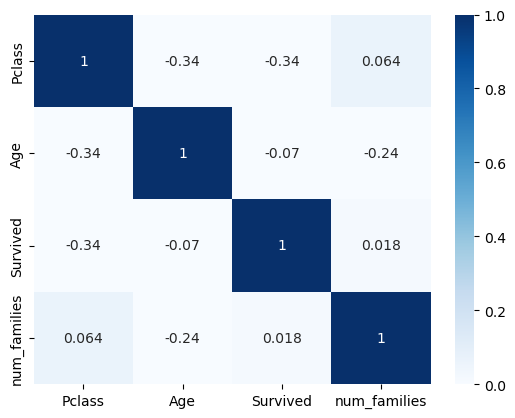

In [14]:
sns.heatmap(corr_mat, annot=True, cmap='Blues', vmin=0, vmax=1)

In [15]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

In [16]:
y=df['Survived']

In [17]:
X=df.drop(columns='Survived')

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
st_scaler=StandardScaler()
st_scaler

StandardScaler()

In [20]:
for_st_scaler=X.select_dtypes('number')

In [21]:
for_st_scaler

,Pclass,Age,num_families
0,3,22.0,1
1,1,38.0,1
2,3,26.0,0
3,1,35.0,1
4,3,35.0,0
...,...,...,...
884,2,27.0,0
885,1,19.0,0
886,3,28.0,3
887,1,26.0,0


In [22]:
scaled=st_scaler.fit_transform(for_st_scaler)
scaled

array([[ 0.82520863, -0.56367407,  0.05785331],
       [-1.57221121,  0.66921696,  0.05785331],
       [ 0.82520863, -0.25545131, -0.5618044 ],
       ...,
       [ 0.82520863, -0.10133993,  1.29716872],
       [-1.57221121, -0.25545131, -0.5618044 ],
       [ 0.82520863,  0.20688282, -0.5618044 ]])

In [23]:
# assign the scaled values to X data frame
X[['Pclass','Age','num_families']]=scaled

In [24]:
X

,Pclass,Age,num_families,Sex_male,Embarked_Q,Embarked_S
0,0.825209,-0.563674,0.057853,True,False,True
1,-1.572211,0.669217,0.057853,False,False,False
2,0.825209,-0.255451,-0.561804,False,False,True
3,-1.572211,0.438050,0.057853,False,False,True
4,0.825209,0.438050,-0.561804,True,False,True
...,...,...,...,...,...,...
884,-0.373501,-0.178396,-0.561804,True,False,True
885,-1.572211,-0.794841,-0.561804,False,False,True
886,0.825209,-0.101340,1.297169,False,False,True
887,-1.572211,-0.255451,-0.561804,True,False,False


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
logr=LogisticRegression()

In [29]:
logr.fit(X_train, y_train)

LogisticRegression()

In [30]:
pred_logr=logr.predict(X_test)
pred_logr

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [31]:
y_test

159    0
125    0
427    0
421    0
564    0
      ..
39     1
90     0
881    0
851    1
636    0
Name: Survived, Length: 178, dtype: int64

In [32]:
comparison=pd.DataFrame({'Actual':y_test, 'Predicted':pred_logr})
comparison

,Actual,Predicted
159,0,0
125,0,0
427,0,0
421,0,0
564,0,0
...,...,...
39,1,1
90,0,0
881,0,0
851,1,1


In [33]:
logr.intercept_

array([1.26441979])

In [34]:
coefficient=logr.coef_.T

In [35]:
coefficient=pd.DataFrame(coefficient, columns=['coefficient'], index=X.columns)

In [36]:
coefficient['abs_coefficient']=coefficient['coefficient'].abs()

In [37]:
coefficient.sort_values('abs_coefficient', ascending=False)

,coefficient,abs_coefficient
Sex_male,-2.572008,2.572008
Pclass,-0.912128,0.912128
Age,-0.451430,0.451430
Embarked_S,-0.360862,0.360862
Embarked_Q,0.285366,0.285366
num_families,-0.238262,0.238262


In [38]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



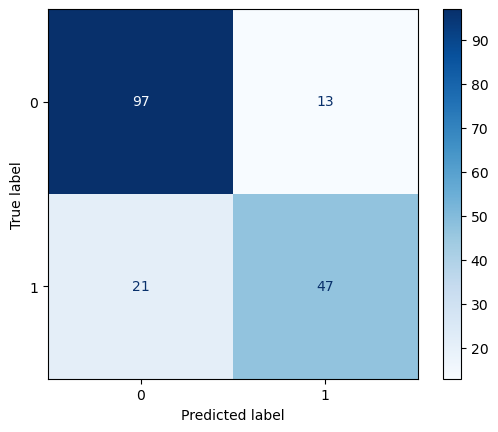

In [39]:
print(classification_report(y_test, pred_logr))
# display ConfusionMatrixDisplay 
ConfusionMatrixDisplay.from_predictions(y_test, pred_logr, cmap='Blues')

In [40]:
from sklearn.metrics import precision_recall_curve

In [41]:
pred_prob=logr.predict_proba(X_test)
pred_prob

array([[0.95006204, 0.04993796],
       [0.83136243, 0.16863757],
       [0.83136243, 0.16863757],
       [0.90689737, 0.09310263],
       [0.91665037, 0.08334963],
       [0.04839678, 0.95160322],
       [0.89446527, 0.10553473],
       [0.14723478, 0.85276522],
       [0.10272171, 0.89727829],
       [0.91534234, 0.08465766],
       [0.83136243, 0.16863757],
       [0.21965069, 0.78034931],
       [0.13871234, 0.86128766],
       [0.25213814, 0.74786186],
       [0.07054867, 0.92945133],
       [0.33373778, 0.66626222],
       [0.30311784, 0.69688216],
       [0.22790297, 0.77209703],
       [0.8730805 , 0.1269195 ],
       [0.87900162, 0.12099838],
       [0.56465998, 0.43534002],
       [0.91799922, 0.08200078],
       [0.86516918, 0.13483082],
       [0.92308627, 0.07691373],
       [0.434678  , 0.565322  ],
       [0.48436052, 0.51563948],
       [0.61772965, 0.38227035],
       [0.27795341, 0.72204659],
       [0.89770413, 0.10229587],
       [0.10678044, 0.89321956],
       [0.

In [42]:
precision, recall, thresholds=precision_recall_curve(y_test,pred_prob[:,1])

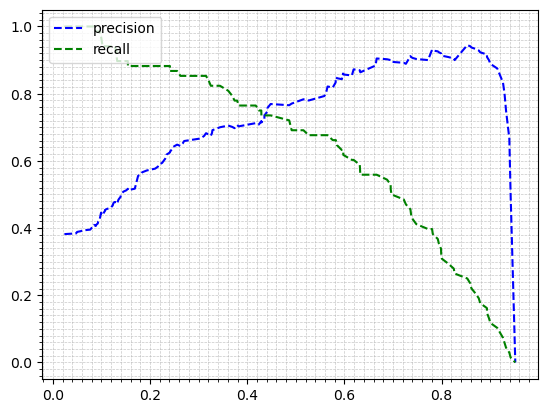

In [43]:
import matplotlib.pyplot as plt 
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.plot(thresholds, precision[:-1], 'b--', label = 'precision')
plt.plot(thresholds, recall[:-1], 'g--', label = 'recall')
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.02))
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(0.02))
plt.legend(loc = 'upper left')

In [44]:
pred_logr2=pred_prob[:,1]>=0.47
pred_logr2

array([False, False, False, False, False,  True, False,  True,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False,  True,  True, False,
        True, False,  True,  True, False, False, False, False, False,
       False, False, False, False,  True, False,  True,  True, False,
       False,  True, False,  True, False, False, False, False,  True,
        True, False, False,  True, False,  True, False,  True, False,
       False,  True, False, False, False, False,  True,  True, False,
        True, False,  True, False, False, False, False, False, False,
        True, False, False, False,  True,  True, False,  True, False,
       False, False,  True, False, False, False,  True, False,  True,
        True, False, False,  True, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False,  True, False,
       False, False,

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.74        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



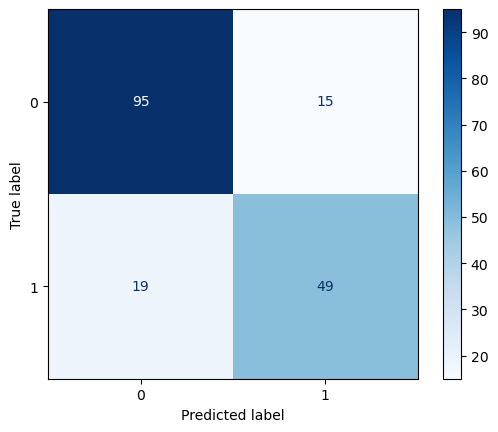

In [45]:
print(classification_report(y_test, pred_logr2))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logr2, cmap='Blues')

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
DTC=DecisionTreeClassifier()

In [48]:
DTC.fit(X_train, y_train)

DecisionTreeClassifier()

In [49]:
preddtc=DTC.predict(X_test)
preddtc

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       110
           1       0.71      0.74      0.72        68

    accuracy                           0.79       178
   macro avg       0.77      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



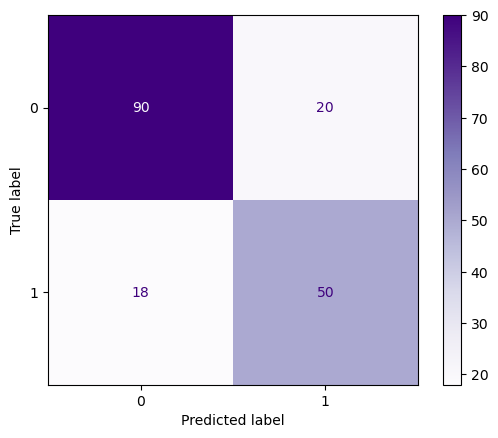

In [50]:
print(classification_report(y_test, preddtc))
ConfusionMatrixDisplay.from_predictions(y_test, preddtc, cmap='Purples')

### Start Of week 13 HW 'DecisionTree Hyperparameter Tuning Homework'

In [52]:
from sklearn import tree

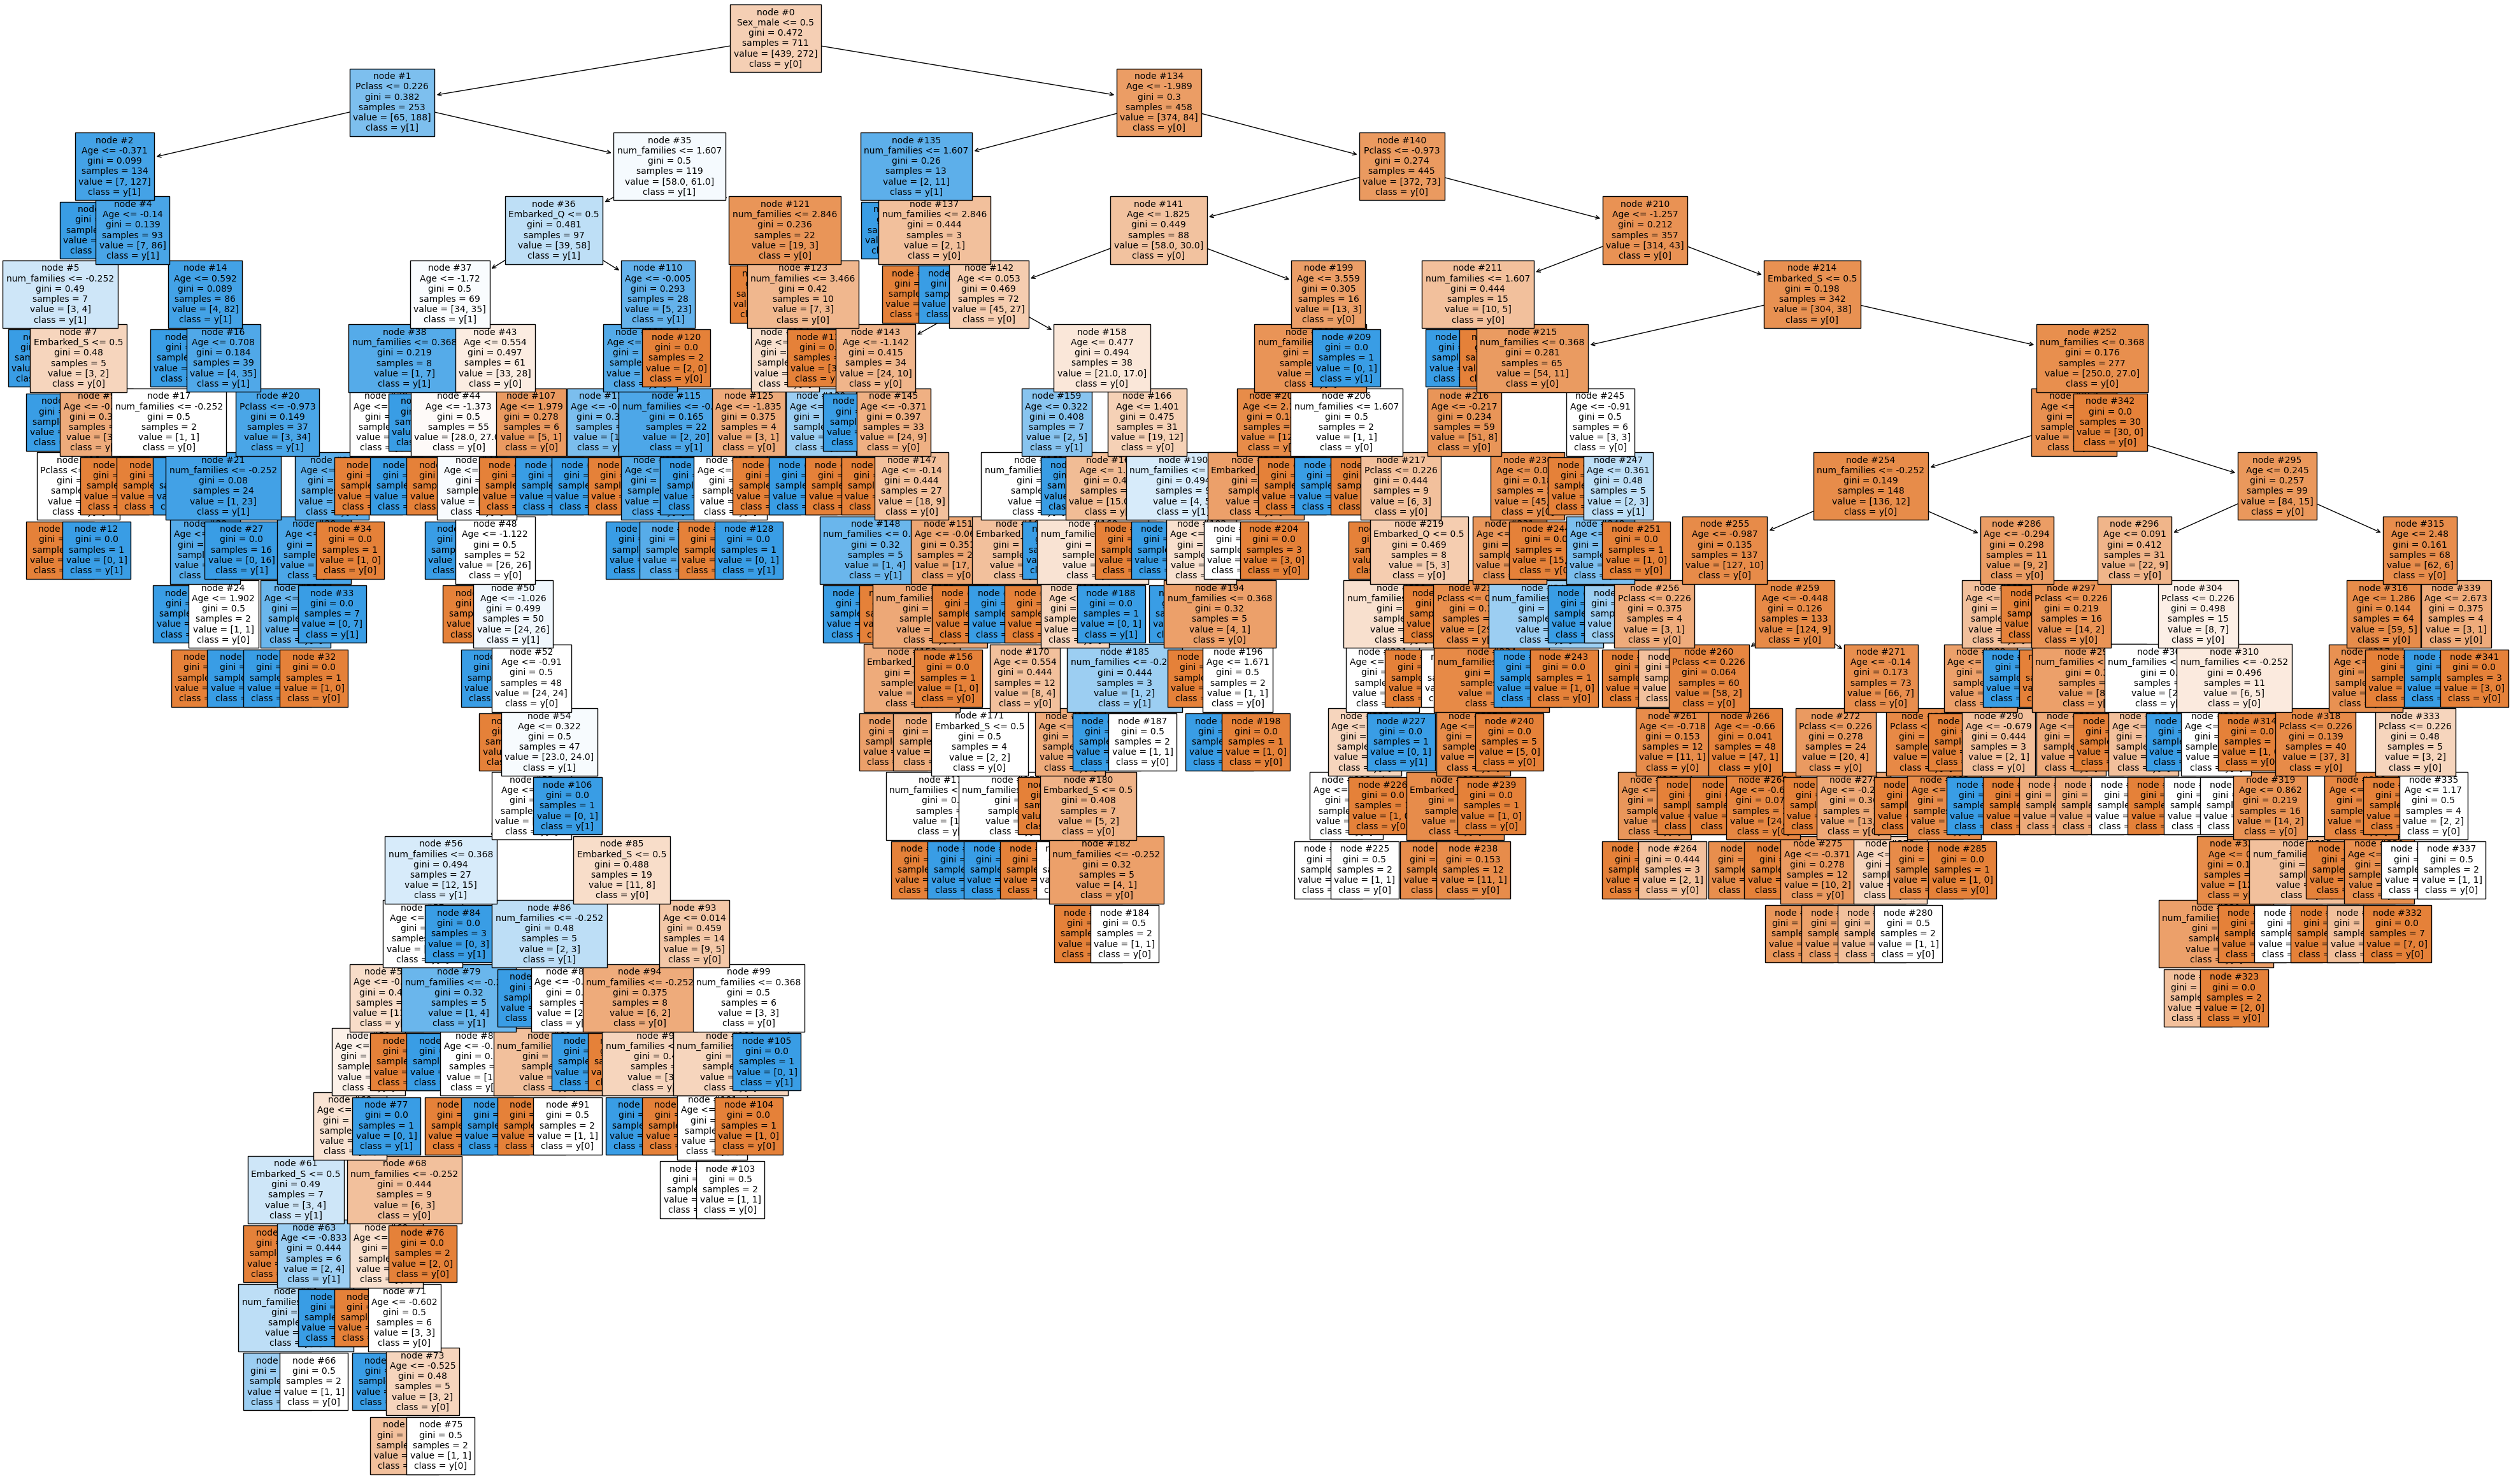

In [53]:
import matplotlib.pyplot as plt  
plt.figure(figsize=(50,30))
tree.plot_tree(DTC,feature_names=X.columns, filled=True,node_ids=True, class_names=True, fontsize=10 )
plt.show()

In [54]:
Importances=DTC.feature_importances_

In [55]:
Importances=pd.DataFrame(Importances, columns=['importances'], index=X.columns).sort_values('importances', ascending=False)

(0.0, 1.0)

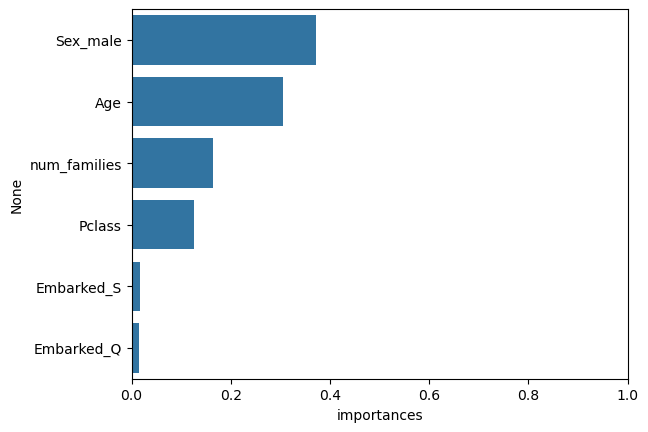

In [56]:
sns.barplot(x=Importances.importances, y=Importances.index)
plt.xlim([0,1])

### Decision Tree: Hyperparameter Tuned

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
dtc = DecisionTreeClassifier()
weights = [{0:0.27, 1:0.73},'balanced',{0:0.5, 1:0.05}]
parameters ={'max_depth':[2,3,4,5,6,7,8,9],
             'min_samples_leaf':[2,5,10,20,25], 'criterion': ['gini','entropy'], 'class_weight': weights }

In [60]:
from sklearn import metrics 
Scorer=metrics.make_scorer(f1_score, pos_label=1)
Scorer

make_scorer(f1_score, response_method='predict', pos_label=1)

In [61]:
gridCV=GridSearchCV(dtc, parameters, scoring=Scorer,cv=5)

In [62]:
dtc_tuned=gridCV.fit(X_train, y_train).best_estimator_
dtc_tuned

DecisionTreeClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=2)

In [63]:
pred_dtc2=dtc_tuned.predict(X_test)

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       110
           1       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178



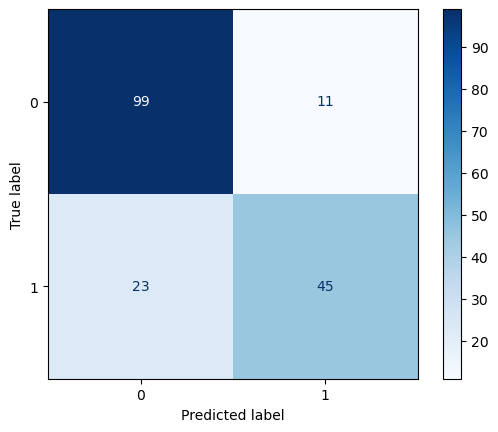

In [64]:
print(classification_report(y_test, pred_dtc2))
ConfusionMatrixDisplay.from_predictions(y_test, pred_dtc2, cmap='Blues')

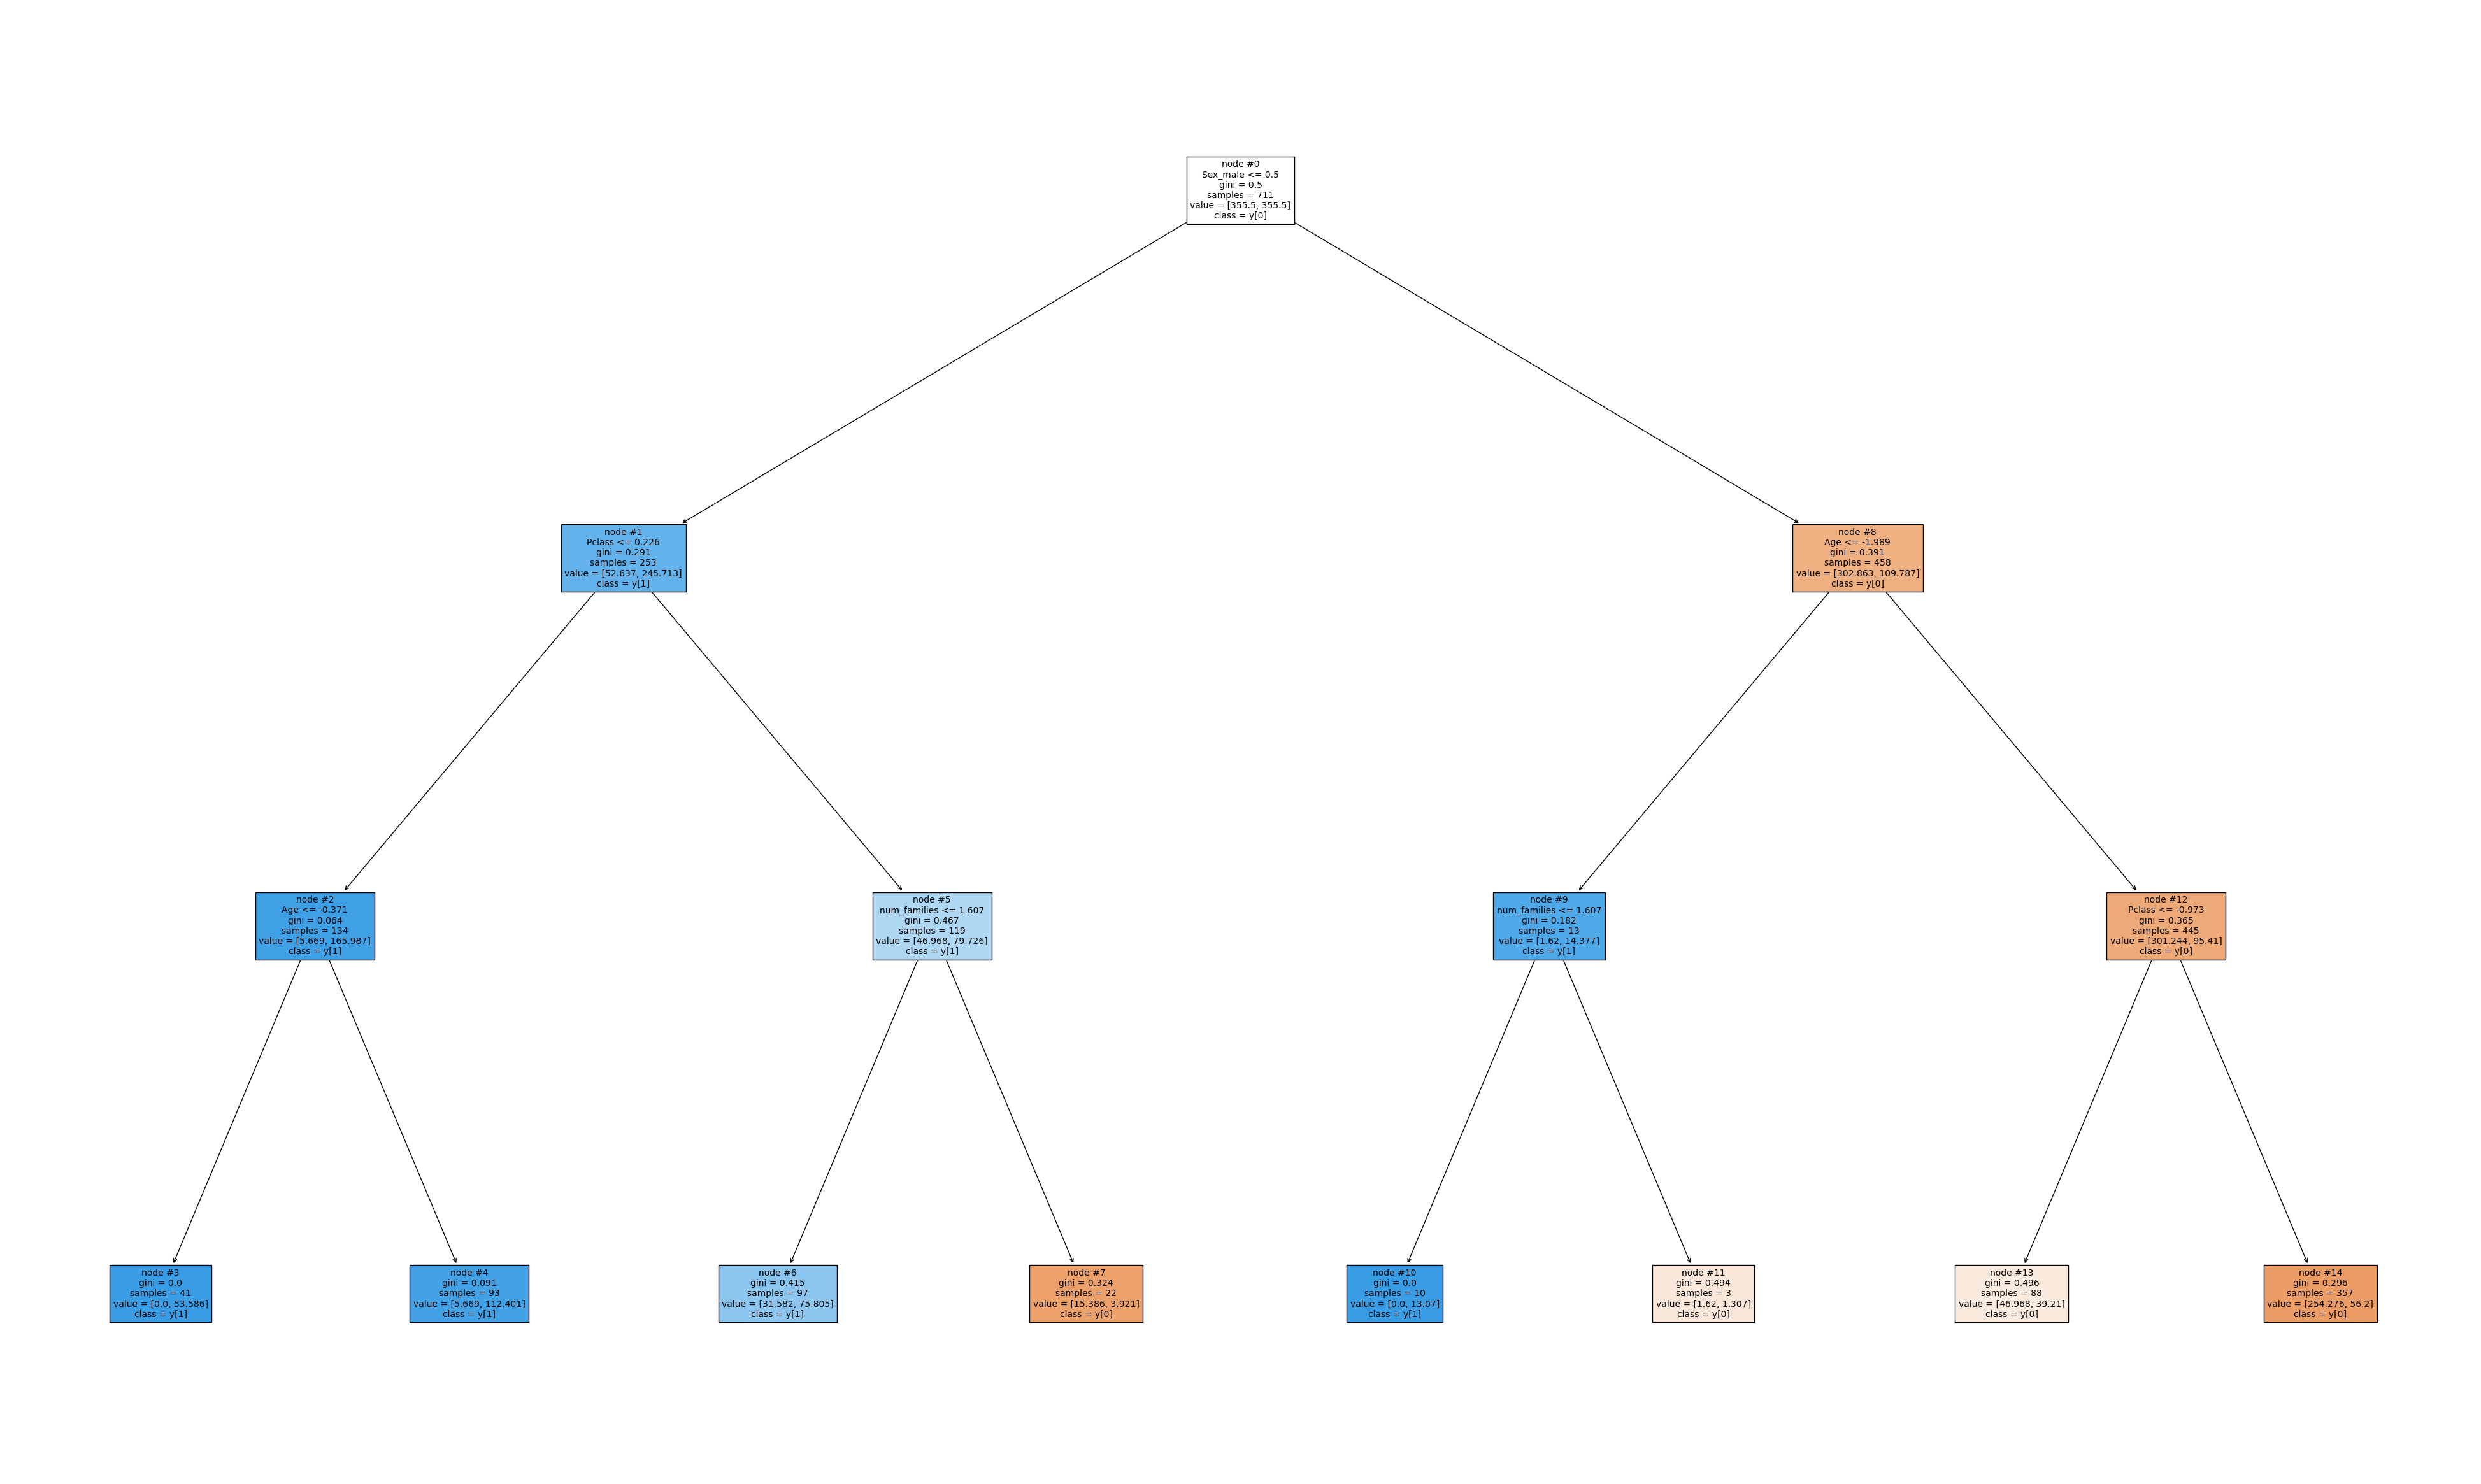

In [65]:
plt.figure(figsize=(50,30))
tree.plot_tree(dtc_tuned,feature_names=X.columns, filled=True,node_ids=True, class_names=True, fontsize=10 )
plt.show()

In [66]:
Importances=dtc_tuned.feature_importances_

In [67]:
Importances=pd.DataFrame(Importances, columns=['importances'], index=X.columns).sort_values('importances', ascending=False)
Importances

,importances
Sex_male,0.682896
Pclass,0.169714
Age,0.085602
num_families,0.061788
Embarked_Q,0.000000
Embarked_S,0.000000


(0.0, 1.0)

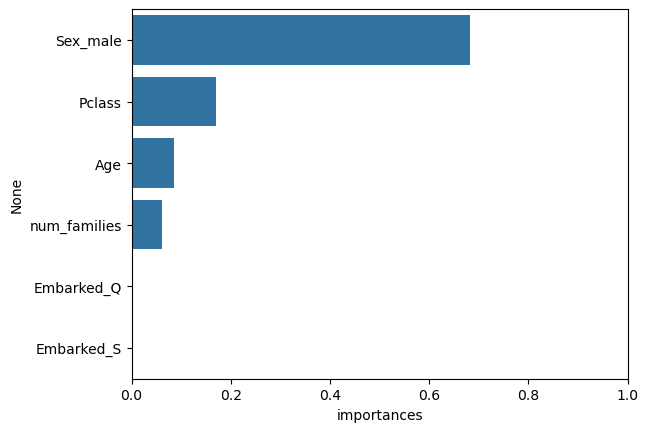

In [68]:
sns.barplot(x=Importances.importances, y=Importances.index)
plt.xlim([0,1])

In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
knr=KNeighborsClassifier()

In [71]:
knr.fit(X_train, y_train)

KNeighborsClassifier()

In [72]:
predknr=knr.predict(X_test)
predknr

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0])

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.76      0.66      0.71        68

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



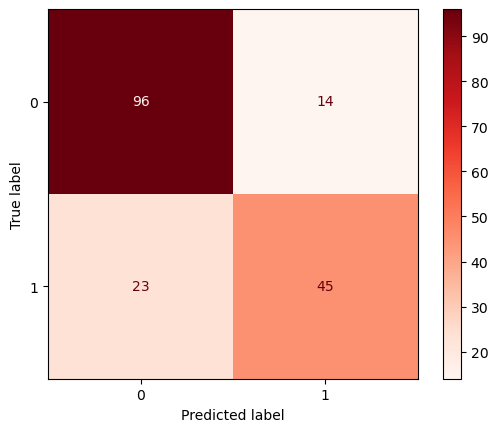

In [73]:
print(classification_report(y_test, predknr))

ConfusionMatrixDisplay.from_predictions(y_test, predknr, cmap='Reds')

In [74]:
f1_logr=f1_score(y_test, pred_logr)
f1_logr2=f1_score(y_test, pred_logr2)
f1_dtc=f1_score(y_test, preddtc)
f1_dtc2=f1_score(y_test, pred_dtc2)
f1_knc=f1_score(y_test, predknr)
recall_logr=recall_score(y_test, pred_logr)
recall_logr2=recall_score(y_test, pred_logr2)
recall_dtc=recall_score(y_test, preddtc)
recall_dtc2=recall_score(y_test, pred_dtc2)
recall_knc=recall_score(y_test, predknr)

In [75]:
 best_model=max((f1_logr, 'Logistic Regression'),(f1_logr2,'Logistic Regression with the Optimal Thresholds, 0.47'),(f1_dtc,'Decision Tree Classifier'),(f1_dtc2,'Decision Tree Classifier Hypterparameter Tuned'),(f1_knc,'KNeighbors Classifier'))

In [76]:
print(f'The best model is {best_model[1]} with f1_socre of {best_model[0]}')

The best model is Logistic Regression with the Optimal Thresholds, 0.47 with f1_socre of 0.7424242424242424


In [77]:
best_model2=max((recall_logr, 'Logistic Regression'),(recall_logr2,'Logistic Regression with the Optimal Thresholds, 0.47'),(recall_dtc,'Decision Tree Classifier'),(recall_dtc2,'Decision Tree Classifier Hyperparameter Tuned'),(recall_knc,'KNeighbors Classifier'))

In [78]:
print(f'The best model is {best_model2[1]} with recall_socre of {best_model2[0]}')

The best model is Decision Tree Classifier with recall_socre of 0.7352941176470589


week 13 HW 'DecisionTree Hyperparameter Tuning Homework Answer(This is also at the top)

The best model is Logistic Regression with the Optimal Thresholds, 0.47 with f1_socre of 0.7424242424242424
The best model is Decision Tree Classifier with recall_socre of 0.7352941176470589